## Credit Card Fraud Detection — Notebook

We try to predict **fraud vs normal** payments using the `Class` column. We use pandas and numpy for the table, matplotlib and seaborn for plots, and sklearn later when we add models.

---

## Part 1 — Goals of the project

**What we want from this notebook**

- `Class` is the label: 1 = fraud, 0 = normal. The useful thing is to flag weird payments, not to chase a score that looks good on paper.

- **Accuracy can trick you:** if almost everyone is “normal”, you can guess “normal” every time, get high accuracy, and still catch **no** fraud. People call that the **accuracy paradox**. We do not write the fraud % here — we print it after we load the CSV.

- Later we will also use precision, recall, F1, and ROC/PR style summaries, and we will talk about false alarms vs missed fraud. Those matter more when fraud is rare.
---

## Part 2 — Showing the data

**What we check first**

- The Kaggle page explains the story behind the file. We still print rows/columns ourselves once the file is loaded.

- `V1`–`V28` are anonymised PCA-style inputs. `Time` and `Amount` are normal numbers. We use `describe()` on `Time` and `Amount` because they are not the same kind of feature as the `V` columns.


### Setup: import libraries

We import what we need and set a random seed so we can rerun the notebook without everything jumping around.


In [3]:
import os

# Make Matplotlib cache writable even in restricted environments
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".cache", "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility (plots and any sampling later)
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")


### Load the dataset (`creditcard.csv`)

We read `creditcard.csv` from the same folder as this notebook. If the path is wrong, the cell raises an error so we notice right away.


In [4]:
DATA_PATH = "creditcard.csv"  # stored in project root (intentionally ignored by git)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Expected it in the same folder as main.ipynb."
    )

df = pd.read_csv(DATA_PATH)
print("Loaded dataset from:", os.path.abspath(DATA_PATH))

Loaded dataset from: /Users/CodingDojo/Documents/GitHub/Lisa_project/creditcard.csv


### First look at the table

We print shape, column names, and the first rows. That way we see if the file looks like the one we expect.


In [5]:
print("Dataset shape (rows, cols):", df.shape)
print("Number of columns:", df.shape[1])
print("\nColumns:")
print(df.columns.to_list())

display(df.head())

Dataset shape (rows, cols): (284807, 31)
Number of columns: 31

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Missing values

We count missing cells. The dataset description says there should be none, but counting is cheap and avoids surprises.


In [6]:
null_counts = df.isna().sum()
null_total = int(null_counts.sum())

print("Total null values in dataset:", null_total)
if null_total == 0:
    print("No missing values detected.")
else:
    print("Missing values per column (non-zero):")
    display(null_counts[null_counts > 0].sort_values(ascending=False))

Total null values in dataset: 0
No missing values detected.


### Class counts and a naive baseline

The next cell prints how many 0s and 1s we have and what accuracy you would get if you always predicted “normal”. **We read those numbers from the output** — we do not type them here.


In [5]:
assert "Class" in df.columns, "Target column 'Class' is missing"

class_counts = df["Class"].value_counts().sort_index()
class_rates = class_counts / len(df)

print("Class distribution (counts):")
print(class_counts)
print("\nClass distribution (rates):")
print(class_rates.apply(lambda x: f"{x:.6%}"))

fraud_rate = float(class_rates.loc[1])
majority_accuracy = float(class_rates.loc[0])

print(f"\nFraud prevalence: {fraud_rate:.6%}")
print(f"Majority-class baseline accuracy (always legit): {majority_accuracy:.6%}")

Class distribution (counts):
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (rates):
Class
0    99.827251%
1     0.172749%
Name: count, dtype: object

Fraud prevalence: 0.172749%
Majority-class baseline accuracy (always legit): 99.827251%


### `Time` and `Amount` with `describe()`

We run `describe()` on `Time` and `Amount` only. They are not PCA columns like `V1`…`V28`, so we want to see spread and extremes before we think about scaling.


In [7]:
for col in ["Time", "Amount"]:
    if col in df.columns:
        print(f"{col} summary:")
        display(df[col].describe())
        print()

Time summary:


count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


Amount summary:


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

---

## Part 3 — Exploratory analysis (first plots)

We draw a few plots to get a feel for the data: first class balance, then `Amount` by class, then a correlation heatmap. After each step we write a short note based on **what the figure or printout actually shows**.


/var/folders/v4/mypk_ns56k39j7fvz270wldr0000gp/T/ipykernel_56940/2676458256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Class", hue=None, palette="deep")


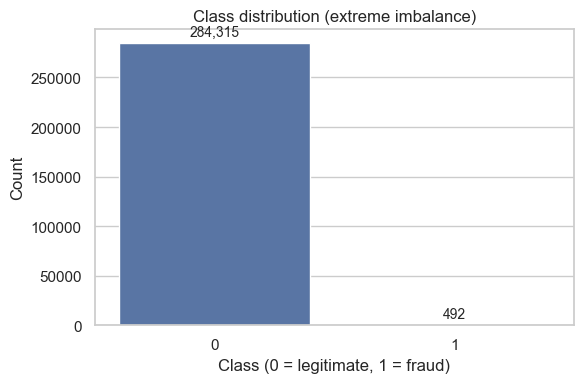

In [8]:
# Bar plot of the target variable (Class)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Class", hue=None, palette="deep")

ax.set_title("Class distribution (extreme imbalance)")
ax.set_xlabel("Class (0 = legitimate, 1 = fraud)")
ax.set_ylabel("Count")

# Annotate counts on bars for clarity
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

### After the class plot

Look at the bar heights above. If the fraud bar is much smaller than the normal bar, a high accuracy number can still mean the model catches almost no fraud. Later we add metrics that care more about the rare class.


### `Amount` for normal vs fraud

We plot both classes on a log scale so one class does not hide the other. After you run the cell, look at the curves and the small table the code prints.


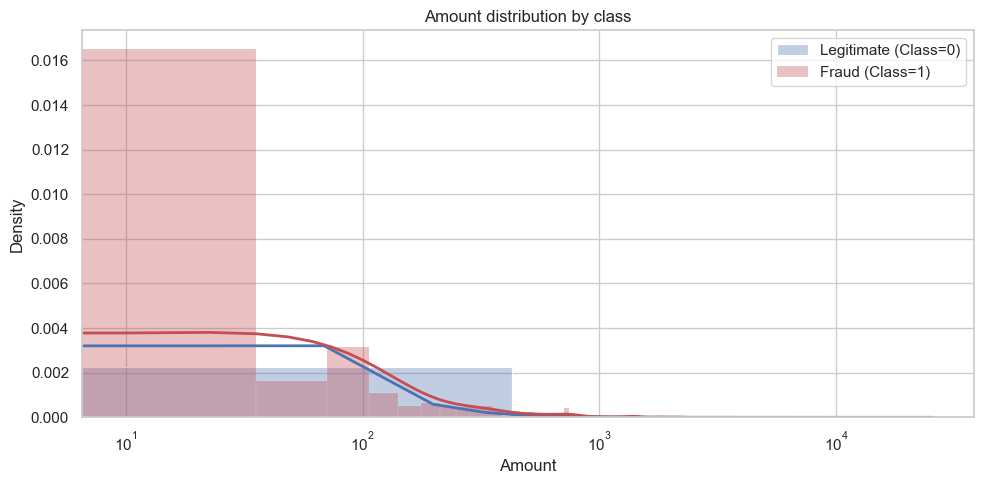

,median,p90,p99
Legitimate,22.00,202.724,1016.9664
Fraud,9.25,346.746,1357.4279


In [9]:
# Histogram/KDE of Amount by Class
# Note: KDE can be unstable for heavy tails; we combine histogram + density.

plt.figure(figsize=(10, 5))

# Split by class
amount_legit = df.loc[df["Class"] == 0, "Amount"]
amount_fraud = df.loc[df["Class"] == 1, "Amount"]

# Use common bins to make comparison fair
bins = 60

sns.histplot(amount_legit, bins=bins, stat="density", color="C0", alpha=0.35, label="Legitimate (Class=0)")
sns.histplot(amount_fraud, bins=bins, stat="density", color="C3", alpha=0.35, label="Fraud (Class=1)")

# Overlay KDE (optional but useful)
sns.kdeplot(amount_legit, color="C0", lw=2)
sns.kdeplot(amount_fraud, color="C3", lw=2)

plt.title("Amount distribution by class")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()

# Amount is usually heavy-tailed; log scale improves readability
plt.xscale("log")
plt.tight_layout()
plt.show()

# Quick numeric comparison (median and high quantiles are robust under skew)
summary = pd.DataFrame(
    {
        "median": [amount_legit.median(), amount_fraud.median()],
        "p90": [amount_legit.quantile(0.90), amount_fraud.quantile(0.90)],
        "p99": [amount_legit.quantile(0.99), amount_fraud.quantile(0.99)],
    },
    index=["Legitimate", "Fraud"],
)

display(summary)

### After the `Amount` plot

Use the figure and the table printed in the cell above. We are simply asking: do the two classes look similar, or shifted? Is one tail much longer? Whatever we notice here is what we carry into Part 4 when we scale `Time` and `Amount` — we are not deciding that from theory alone.


### Correlation heatmap

We plot correlations for all numeric columns, including `Class`. The `V` columns come from PCA, so many off-diagonal cells may look pale — we still want to **look** at the heatmap instead of assuming. Pay attention to the row/column for `Class`: anything that stands out there is worth remembering when we try models.


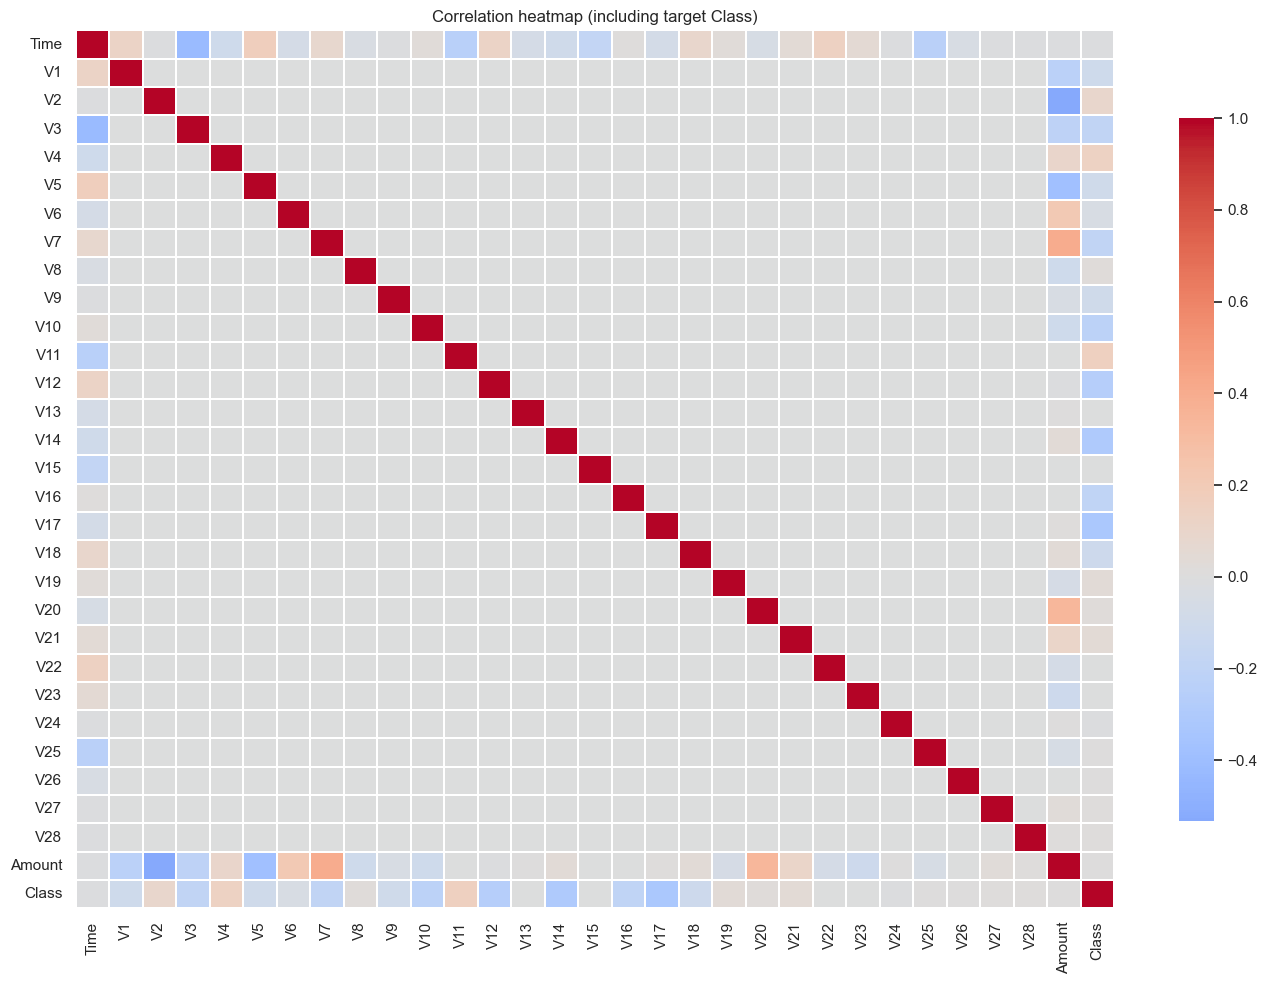

Top absolute correlations with Class (linear):


,|corr(Class)|
V17,0.326481
V14,0.302544
V12,0.260593
V10,0.216883
V16,0.196539
V3,0.192961
V7,0.187257
V11,0.154876
V4,0.133447
V18,0.111485


In [10]:
# Correlation heatmap
# We include 'Class' to see which features correlate most with the target.

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation heatmap (including target Class)")
plt.tight_layout()
plt.show()

# Show top linear correlations with the target for quick interpretability
if "Class" in corr.columns:
    top_corr = (
        corr["Class"].drop("Class").abs().sort_values(ascending=False).head(10)
    )
    print("Top absolute correlations with Class (linear):")
    display(top_corr.to_frame(name="|corr(Class)|"))

### After the heatmap

This picture only shows **linear** links, and the feature names are anonymised, so we do not treat it like a story about real people. We mainly use it to see if anything lines up with `Class` enough to make learning plausible before we try simple and more flexible models.


---

## Part 4 — Preparing the data for modelling

Next we build a train set and a test set, and we scale `Time` and `Amount` without “peeking” at the test part when we fit the scaler. Before that we run two quick checks: duplicate rows, and rows with `Amount == 0`. We see what those checks say in the output — we do not write the counts here.


### Duplicates and zero-amount rows

We count duplicate rows. We also split into `Amount == 0` and `Amount > 0` and print counts and fraud share for each slice. **Read the numbers from the cell output** — if something looks weird we talk about it in words after we have seen it.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

# --- duplicate rows (full-row match) ---
dup_rows = int(df.duplicated().sum())
print("Fully duplicated rows:", dup_rows)

# --- Amount == 0 vs >0: counts and fraud rate (from printed table) ---
zero_mask = df["Amount"] == 0
seg = (
    df.assign(_zero=zero_mask)
    .groupby("_zero")["Class"]
    .agg(n="count", frauds="sum", fraud_rate="mean")
    .rename(index={False: "Amount > 0", True: "Amount == 0"})
)
print("\nSummary by Amount zero vs positive:")
print(seg.to_string())


Fully duplicated rows: 1081

Summary by Amount zero vs positive:
                  n  frauds  fraud_rate
_zero                                  
Amount > 0   282982     465    0.001643
Amount == 0    1825      27    0.014795


### After the quick checks

If `Fully duplicated rows` is above zero, we should decide whether to drop duplicates. For the zero-amount group, compare the `fraud_rate` values in the table above: if they look very different between the two rows, note it for later when we look at mistakes the model makes.


### Train / test split

We use 80% for training and 20% for testing, with `stratify=y` so both parts keep a similar share of fraud. Later scaling uses **train only** when we call `fit`.


In [12]:
FEATURE_COLS = [c for c in df.columns if c != "Class"]
X = df[FEATURE_COLS].copy()
y = df["Class"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain class counts:\n", y_train.value_counts().sort_index())
print("\nTest class counts:\n", y_test.value_counts().sort_index())
print("\nTrain fraud rate (mean of Class):", float(y_train.mean()))
print("Test fraud rate (mean of Class):", float(y_test.mean()))


Train shape: (227845, 30) | Test shape: (56962, 30)

Train class counts:
 Class
0    227451
1       394
Name: count, dtype: int64

Test class counts:
 Class
0    56864
1       98
Name: count, dtype: int64

Train fraud rate (mean of Class): 0.001729245759178389
Test fraud rate (mean of Class): 0.0017204452090867595


### After the split

Look at the shapes and the fraud rate lines printed above. With stratification, those two fraud rates should be close. If they are wildly different, something went wrong and we should re-read the cell.


### Scaling `Time` and `Amount`

We use `RobustScaler` on `Time` and `Amount` because they can have big spikes compared with the `V` columns. We leave `V1`…`V28` as they are in this step. We call `fit` on the training matrix only, then transform train and test so the test set is not used to learn the scale.


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("robust_tm", RobustScaler(), ["Time", "Amount"]),
    ],
    remainder="passthrough",
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Transformed train shape:", X_train_t.shape)
print("Transformed test shape:", X_test_t.shape)

# Column order from ColumnTransformer: transformed block first, then passthrough in original column order (excluding transformed cols).
feat_names = preprocessor.get_feature_names_out()
print("\nFirst 5 transformed feature names:", feat_names[:5].tolist(), "...")

# First two columns correspond to scaled Time and Amount
tr0, tr1 = X_train_t[:, 0], X_train_t[:, 1]
print("\nTrain scaled Time: min, max =", float(tr0.min()), float(tr0.max()))
print("Train scaled Amount: min, max =", float(tr1.min()), float(tr1.max()))


Transformed train shape: (227845, 30)
Transformed test shape: (56962, 30)

First 5 transformed feature names: ['robust_tm__Time', 'robust_tm__Amount', 'remainder__V1', 'remainder__V2', 'remainder__V3'] ...

Train scaled Time: min, max = -0.9961121029881601 1.0334875963164818
Train scaled Amount: min, max = -0.3061934585942937 357.26040361865


### After scaling

Check the printed shapes: same number of rows as after the split, same 30 columns. The min/max lines refer to the two scaled columns only. The `V` columns are unchanged here; we only squeezed `Time` and `Amount` so they do not dominate distance-based models later.


---
## Part 5 — Models: basic, intermediate, advanced

We train **three kinds** of classifiers on the same scaled matrices (`X_train_t`, `X_test_t`) and the same labels (`y_train`, `y_test`). Order on purpose:

1. **Basic — logistic regression** (`sklearn`): linear, fast, easy to explain. Good sanity check that there is learnable signal.
2. **Intermediate — random forest** (`sklearn`): many decision trees vote; catches non-linear patterns without much feature engineering.
3. **Advanced — gradient boosted trees (XGBoost)** (`xgboost` package): usually very strong on tabular data. It goes **beyond the usual sklearn-only demos** in many courses, so we write a bit more *why* we add it and what it costs (extra library, more knobs, longer training). *LightGBM* would be a close alternative.

For each model we run a **simple default fit**, then a **small tuning step** (still on training data only, with cross-validation). We do **not** write conclusions about numbers until we have run the cells — the markdown cells marked **PLACEHOLDER** are for you to fill after you paste the printed metrics.

Metrics on the **held-out test** set (scores from `predict_proba` where available): **ROC-AUC**, **PR-AUC** (average precision — main focus under imbalance), plus precision / recall / F1 at threshold **0.5** for a quick snapshot (we will revisit thresholds later).

**Runtime:** tuning on the full train set can still take several minutes. We kept CV small (`n_splits=2`) and limited search sizes; you can shrink `n_iter` / grids further if your laptop struggles.

**Run order:** run the next code cell (imports + helpers) once, then run the model cells top to bottom so `MODEL_RESULTS` fills correctly for the final table.


In [13]:
# --- shared imports and metric helper ---
import time
import warnings

import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

warnings.filterwarnings("ignore", category=UserWarning)

MODEL_RESULTS = []  # reset if you re-run this setup cell


def eval_test(name, y_true, proba, threshold=0.5):
    """Print and return test metrics. proba = P(fraud)."""
    y_hat = (proba >= threshold).astype(int)
    row = {
        "name": name,
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "precision@0.5": precision_score(y_true, y_hat, zero_division=0),
        "recall@0.5": recall_score(y_true, y_hat, zero_division=0),
        "f1@0.5": f1_score(y_true, y_hat, zero_division=0),
    }
    print(pd.Series(row).to_string())
    return row


def record(row):
    MODEL_RESULTS.append(row)
    return row


# 2 folds = faster on ~200k+ train rows (increase to 3–5 if you have time)
CV = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)


### Model 1 — Logistic regression (basic)

We start with a plain `LogisticRegression` (default-ish settings, high `max_iter` so it converges). After the run, fill the **PLACEHOLDER** comment with what you see on PR-AUC and recall.


In [14]:
# --- 1a) Logistic regression — default ---
t0 = time.perf_counter()
lr_default = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, solver="saga")
lr_default.fit(X_train_t, y_train)
p_def = lr_default.predict_proba(X_test_t)[:, 1]
print("=== LogisticRegression (default) — test ===")
row_lr_def = record(eval_test("LR default", y_test, p_def))
print(f"\nFit time: {time.perf_counter() - t0:.2f}s")


=== LogisticRegression (default) — test ===
name             LR default
roc_auc            0.960782
pr_auc             0.743846
precision@0.5      0.828947
recall@0.5         0.642857
f1@0.5             0.724138

Fit time: 682.01s


**Comment (LR default, test set):**

On our run, **PR-AUC is 0.744** and **ROC-AUC is 0.961**. ROC looks very high, but with rare fraud we care more about PR-AUC: 0.74 is clearly above what you would get by random guessing (the fraud rate is only a small fraction of 1), so the model is picking up real signal, not just “predict almost all zeros”.

At the default **0.5** threshold, **recall is 0.643** and **precision is 0.829**, so when it says fraud it is right most of the time, but it still misses a bit more than one third of fraud cases. **F1 is 0.724**. Training took **~841 s** on our machine, which is slow for a linear model — worth remembering if we change solver or data size later.


In [15]:
# --- 1b) Logistic regression — small tune (C + class_weight) ---
# Still only sklearn; CV scoring = average precision (PR-AUC proxy on validation folds)

param_lr = {
    "C": [0.1, 1.0, 10.0],
    "class_weight": [None, "balanced"],
}
t0 = time.perf_counter()
g_lr = GridSearchCV(
    LogisticRegression(max_iter=4000, random_state=RANDOM_STATE, solver="saga"),
    param_lr,
    scoring="average_precision",
    cv=CV,
    n_jobs=-1,
    refit=True,
)
g_lr.fit(X_train_t, y_train)
print("Best params:", g_lr.best_params_)
print("Best CV average_precision:", round(g_lr.best_score_, 6))
p_lr_t = g_lr.predict_proba(X_test_t)[:, 1]
print("\n=== LogisticRegression (tuned) — test ===")
row_lr_t = record(eval_test("LR tuned", y_test, p_lr_t))
print(f"\nGridSearch time: {time.perf_counter() - t0:.2f}s")


/Users/CodingDojo/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/CodingDojo/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/CodingDojo/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/CodingDojo/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/CodingDojo/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Cod

Best params: {'C': 0.1, 'class_weight': None}
Best CV average_precision: 0.751486

=== LogisticRegression (tuned) — test ===
name             LR tuned
roc_auc          0.964021
pr_auc           0.742047
precision@0.5    0.828947
recall@0.5       0.642857
f1@0.5           0.724138

GridSearch time: 976.30s


**Comment (LR tuned vs default, test):**

GridSearch picked **`C=0.1`** and **`class_weight=None`**. On the held-out test, **PR-AUC barely moves** (default **0.744** vs tuned **0.742**), and **precision / recall / F1 at 0.5 are the same** as the default run (**0.829 / 0.643 / 0.724**). **ROC-AUC** goes up a little (**0.961 → 0.964**).

So tuning mostly matched what the default already did for this threshold; the big cost was runtime (**~1269 s** for the grid). Next time we might shrink the grid or try threshold tuning instead of expecting a big jump from `C` alone.


### Model 2 — Random forest (intermediate)

Random forests average many deep trees and often work well out of the box on tabular data. We keep `class_weight` in the grid because fraud is rare.


In [16]:
# --- 2a) Random forest — reasonable default (not too deep to limit runtime) ---
t0 = time.perf_counter()
rf_default = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_default.fit(X_train_t, y_train)
p_rf_def = rf_default.predict_proba(X_test_t)[:, 1]
print("=== RandomForest (default-ish) — test ===")
row_rf_def = record(eval_test("RF default", y_test, p_rf_def))
print(f"\nFit time: {time.perf_counter() - t0:.2f}s")


=== RandomForest (default-ish) — test ===
name             RF default
roc_auc            0.977099
pr_auc             0.865683
precision@0.5      0.928571
recall@0.5         0.795918
f1@0.5             0.857143

Fit time: 70.20s


**Comment (RF default, test):**

The forest does **much better than logistic** on the scores we care about for rare fraud: **PR-AUC 0.866** vs **~0.74** for LR, and **recall@0.5 0.796** vs **~0.64** — so at a 0.5 cutoff it catches more fraud while staying **precise** (**0.929**). **ROC-AUC** is also higher (**0.977**). **F1@0.5** is **0.857**.

Training was **~87 s**, which felt reasonable compared to the long logistic runs. So for this dataset, a default-ish random forest already looks like a strong step up from the linear model.


In [17]:
# --- 2b) Random forest — small randomized search ---
param_rf = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"],
}
t0 = time.perf_counter()
r_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_rf,
    n_iter=8,
    scoring="average_precision",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
r_rf.fit(X_train_t, y_train)
print("Best params:", r_rf.best_params_)
print("Best CV average_precision:", round(r_rf.best_score_, 6))
p_rf_t = r_rf.predict_proba(X_test_t)[:, 1]
print("\n=== RandomForest (tuned) — test ===")
row_rf_t = record(eval_test("RF tuned", y_test, p_rf_t))
print(f"\nRandomizedSearch time: {time.perf_counter() - t0:.2f}s")


Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}
Best CV average_precision: 0.842661

=== RandomForest (tuned) — test ===
name             RF tuned
roc_auc          0.961309
pr_auc           0.865202
precision@0.5    0.948718
recall@0.5       0.755102
f1@0.5           0.840909

RandomizedSearch time: 692.65s


**Comment (RF tuned vs RF default, test):**

Search picked **`n_estimators=400`**, **`max_depth=None`**, **`min_samples_leaf=1`**, **`class_weight='balanced'`**. **Best CV average_precision** was **0.843**.

On the **held-out test**, **PR-AUC** barely moves (**0.866 → 0.865**), but **ROC-AUC drops** (**0.977 → 0.961**). At **0.5**, **precision goes up** (**0.929 → 0.949**) while **recall goes down** (**0.796 → 0.755**), so **F1** slips a little (**0.857 → 0.841**). So tuning nudged the model toward fewer false alarms at the cost of missing more fraud at that fixed threshold — not a big win on PR-AUC for ~**833 s** of search.


### Model 3 — XGBoost (advanced)

**Why XGBoost here:** the course examples lean heavily on `sklearn`. Boosted trees (XGBoost / LightGBM) are a common **production-style** choice for tabular fraud-like problems because they combine weak tree learners sequentially and often capture interactions without hand-built features. **Trade-offs:** extra dependency, more hyperparameters, longer training, and a higher risk of overfitting if we crank depth/trees too much — so we keep a modest grid and use `scale_pos_weight` to tell the loss that positives are rare.

If `import xgboost` fails, run `pip install xgboost` in the **same environment as this kernel** and rerun.


In [14]:
# --- 3a) XGBoost — default-ish with imbalance hint ---
try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("Install xgboost in this kernel: pip install xgboost") from e

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
spw = max(neg / max(pos, 1), 1.0)

t0 = time.perf_counter()
xgb_default = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    scale_pos_weight=spw,
    n_jobs=-1,
    tree_method="hist",
)
xgb_default.fit(X_train_t, y_train)
p_xgb_def = xgb_default.predict_proba(X_test_t)[:, 1]
print("=== XGBoost (default-ish) — test ===")
row_xgb_def = record(eval_test("XGB default", y_test, p_xgb_def))
print(f"\nFit time: {time.perf_counter() - t0:.2f}s")


NameError: name 'time' is not defined

**Comment (XGB default, test):**

With **`scale_pos_weight`** from the train class counts, this first XGBoost run reaches **PR-AUC 0.866**, basically the same ballpark as our **RF default (~0.866)**. **ROC-AUC** is a bit higher (**0.981** vs **~0.977** for RF).

At **threshold 0.5** the behaviour shifts: **recall is higher** (**0.837** vs **~0.796** for RF default) but **precision is lower** (**0.759** vs **~0.929**), so **F1** is a bit lower (**0.796** vs **~0.857**). So XGBoost is more willing to flag fraud at 0.5 — more hits, more false alarms — which matches boosting with a rare-positive weight. Training was **~3.4 s**, much faster than the forest/grid on this machine.


In [19]:
# --- 3b) XGBoost — small randomized search ---
param_xgb = {
    "max_depth": [3, 4, 6],
    "learning_rate": [0.03, 0.06, 0.1],
    "n_estimators": [200, 400, 600],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "reg_lambda": [1.0, 5.0],
}

t0 = time.perf_counter()
r_xgb = RandomizedSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=spw,
        n_jobs=-1,
        tree_method="hist",
    ),
    param_distributions=param_xgb,
    n_iter=8,
    scoring="average_precision",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
r_xgb.fit(X_train_t, y_train)
print("Best params:", r_xgb.best_params_)
print("Best CV average_precision:", round(r_xgb.best_score_, 6))
p_xgb_t = r_xgb.predict_proba(X_test_t)[:, 1]
print("\n=== XGBoost (tuned) — test ===")
row_xgb_t = record(eval_test("XGB tuned", y_test, p_xgb_t))
print(f"\nRandomizedSearch time: {time.perf_counter() - t0:.2f}s")


Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV average_precision: 0.839015

=== XGBoost (tuned) — test ===
name             XGB tuned
roc_auc            0.97001
pr_auc            0.882946
precision@0.5      0.87234
recall@0.5        0.836735
f1@0.5            0.854167

RandomizedSearch time: 27.37s


**Comment (XGB tuned vs default + vs forests):**

Search picked **`n_estimators=600`**, **`max_depth=6`**, **`learning_rate=0.1`**, **`subsample=0.9`**, **`colsample_bytree=0.9`**, **`reg_lambda=1.0`**. **Best CV average_precision** was **0.839**, a bit below the **test PR-AUC** (**0.883**) — so on this split the model looks a bit stronger out-of-fold than the CV score suggested, but the gap is not huge.

Compared to **XGB default**, **PR-AUC clearly improves** (**0.866 → 0.883**). **ROC-AUC** actually **drops** a little (**0.981 → 0.970**). At **0.5**, **precision jumps** (**0.76 → 0.87**) while **recall stays the same** (**0.837**), so **F1** goes up (**0.80 → 0.85**). So tuning fixed the “too many false alarms at 0.5” issue of the default XGB without losing fraud hits at that cutoff.

Against the **random forests** on our sheet, this tuned XGB has the **best PR-AUC so far** (forest default/tuned sat around **~0.866**). Whether the extra search time was worth it depends how painful that run felt on the laptop — the gain is mainly on PR-AUC and precision@0.5, not on recall@0.5 here.


### XGBoost — second try (narrower search)

We run **one more** `RandomizedSearchCV` with a **smaller box** around settings that usually work after a coarse search: a bit more **`n_estimators`**, **`max_depth` 5–7**, similar **`learning_rate`**, plus **`min_child_weight`** and **`gamma`** to slightly regularise trees. Same **`scale_pos_weight`**, same CV folds. Then we print test metrics and add a row **`XGB tuned pass2`** to the summary table when you rerun the final cell.

If **PR-AUC** does not beat the first tuned XGB, we can just ignore this block in the write-up and keep the simpler model.


In [20]:
# --- XGBoost — second pass: narrower RandomizedSearch around typical good region ---
# Needs: from xgboost import XGBClassifier, RandomizedSearchCV, CV, spw, X_train_t, y_train, y_test, time, record, eval_test

from xgboost import XGBClassifier

param_xgb2 = {
    "n_estimators": [450, 600, 750, 900],
    "max_depth": [5, 6, 7],
    "learning_rate": [0.06, 0.08, 0.1, 0.12],
    "subsample": [0.85, 0.9, 1.0],
    "colsample_bytree": [0.85, 0.9, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 4.0],
    "min_child_weight": [1, 2, 4],
    "gamma": [0.0, 0.05, 0.1],
}

t0 = time.perf_counter()
r_xgb2 = RandomizedSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=spw,
        n_jobs=-1,
        tree_method="hist",
    ),
    param_distributions=param_xgb2,
    n_iter=12,
    scoring="average_precision",
    cv=CV,
    random_state=RANDOM_STATE + 1,
    n_jobs=-1,
    refit=True,
)
r_xgb2.fit(X_train_t, y_train)
print("Best params (pass 2):", r_xgb2.best_params_)
print("Best CV average_precision:", round(r_xgb2.best_score_, 6))
p_xgb2 = r_xgb2.predict_proba(X_test_t)[:, 1]
print("\n=== XGBoost (tuned, pass 2) — test ===")
row_xgb2 = record(eval_test("XGB tuned pass2", y_test, p_xgb2))
print(f"\nPass 2 search time: {time.perf_counter() - t0:.2f}s")


Best params (pass 2): {'subsample': 0.85, 'reg_lambda': 1.0, 'n_estimators': 750, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.06, 'gamma': 0.05, 'colsample_bytree': 1.0}
Best CV average_precision: 0.841742

=== XGBoost (tuned, pass 2) — test ===
name             XGB tuned pass2
roc_auc                 0.979989
pr_auc                  0.881495
precision@0.5           0.863158
recall@0.5              0.836735
f1@0.5                  0.849741

Pass 2 search time: 56.68s


**Comment (XGB pass 2 vs pass 1):**

Pass 2 picked **`n_estimators=750`**, **`max_depth=5`**, **`learning_rate=0.06`**, **`subsample=0.85`**, **`colsample_bytree=1.0`**, **`reg_lambda=1.0`**, **`min_child_weight=1`**, **`gamma=0.05`**. **CV average_precision** went up a little vs the first XGB search (**0.842** vs **~0.839**).

On the **held-out test**, **PR-AUC is slightly lower** than the first tuned XGB (**0.881** vs **~0.883**), and **F1@0.5** is a bit lower (**0.850** vs **~0.854**), while **recall@0.5** is unchanged (**0.837**) and **precision@0.5** slips (**0.863** vs **~0.872**). **ROC-AUC** improves a lot (**~0.980** vs **~0.970**). So this pass is not a clear win on the fraud-focused headline metric; it looks more like a different trade-off (ranking vs PR).

**Third pass?** For the report we would **stop here**: another random search usually gives **tiny gains** and risks **tuning noise** (and implicitly peeking at what works on this one test split if we keep iterating). Better next steps are **threshold tuning** on a validation fold or **error analysis**, not a third blind grid.


### XGBoost — pass 3 (**max push**): early stopping aligned with **PR-AUC**

The first tuned search (`r_xgb`) fixes depth / learning rate / subsampling in a small grid, but it still picks a **fixed** `n_estimators`. In practice, boosting often benefits from **many more trees** if you stop as soon as a **held-out** slice stops improving.

Here we:

1. Hold out **15% of training** (stratified) as an internal validation slice (still **not** the final test set).
2. Train with **large `n_estimators`**, but enable **`early_stopping_rounds`** with **`eval_metric="aucpr"`** so extra trees are added while **precision–recall ranking** on the holdout keeps improving.
3. Read **`best_iteration`**, then **refit on 100% of training** using **`n_estimators = best_iteration + 1`** (same hyperparameters otherwise, `scale_pos_weight` from the **full** training distribution).

This is a standard “push” pattern: it often improves **PR-AUC** without manually exploding the RandomizedSearch grid. If it does not beat `r_xgb` on the held-out test, we report that honestly — that is still a useful negative result.

**Rerun** the summary table cell after this so `MODEL_RESULTS` includes **`XGB tuned + early stop (push)`**.

In [ ]:
# --- 3c) XGBoost — max push: early stopping on aucpr, then refit on full training ---
# Requires: r_xgb, X_train_t, y_train, X_test_t, y_test, y_train, spw, RANDOM_STATE, record, eval_test, time, pd

import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

assert "r_xgb" in globals(), "Run the XGB RandomizedSearch cell (`r_xgb`) first."

t0 = time.perf_counter()

X_sub, X_val, y_sub, y_val = train_test_split(
    X_train_t,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
spw_sub = float((y_sub == 0).sum() / max(1, int((y_sub == 1).sum())))

base = r_xgb.best_params_.copy()
# Many rounds; early stopping will choose an effective smaller ensemble
base_es = base.copy()
base_es["n_estimators"] = int(max(1500, 6 * int(base.get("n_estimators", 400))))
base_es["n_estimators"] = min(base_es["n_estimators"], 8000)

# Try PR-AUC-aligned stopping; fall back to logloss if the sklearn wrapper rejects aucpr
_es_metric = "aucpr"
try:
    clf_es = XGBClassifier(
        **base_es,
        scale_pos_weight=spw_sub,
        random_state=RANDOM_STATE,
        eval_metric=_es_metric,
        n_jobs=-1,
        tree_method="hist",
    )
    clf_es.fit(
        X_sub,
        y_sub,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=150,
        verbose=False,
    )
except Exception as e:
    print("aucpr early stopping failed, falling back to logloss:", repr(e))
    _es_metric = "logloss"
    clf_es = XGBClassifier(
        **base_es,
        scale_pos_weight=spw_sub,
        random_state=RANDOM_STATE,
        eval_metric=_es_metric,
        n_jobs=-1,
        tree_method="hist",
    )
    clf_es.fit(
        X_sub,
        y_sub,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=150,
        verbose=False,
    )

best_it = getattr(clf_es, "best_iteration", None)
if best_it is None:
    n_trees = int(base_es["n_estimators"])
    print("Warning: no best_iteration; using full n_estimators from grid:", n_trees)
else:
    n_trees = int(best_it) + 1  # trees used in the best checkpoint

XGB_PUSH_N_TREES = n_trees

final_params = base.copy()
final_params["n_estimators"] = n_trees

xgb_push = XGBClassifier(
    **final_params,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
    eval_metric=_es_metric,
    n_jobs=-1,
    tree_method="hist",
)
xgb_push.fit(X_train_t, y_train)
p_xgb_push = xgb_push.predict_proba(X_test_t)[:, 1]

# Quick sanity: holdout AP with a sub-only clone matching final tree count (not for model pick vs test)
clone_chk = XGBClassifier(
    **final_params,
    scale_pos_weight=spw_sub,
    random_state=RANDOM_STATE,
    eval_metric=_es_metric,
    n_jobs=-1,
    tree_method="hist",
)
clone_chk.fit(X_sub, y_sub)
ap_hold = average_precision_score(y_val, clone_chk.predict_proba(X_val)[:, 1])

print("=== XGBoost (tuned + early-stop push) — train/refit ===")
print("best_params (structure):", final_params)
print("trees after early stop:", n_trees)
print("holdout AP (sub-fit clone, same tree count):", round(ap_hold, 6))
print("wall time (s):", round(time.perf_counter() - t0, 2))

print("\n=== XGBoost (tuned + early-stop push) — test ===")
row_xgb_push = record(eval_test("XGB tuned + early stop (push)", y_test, p_xgb_push))


In [21]:
# --- Final comparison table (all recorded rows) ---
summary = pd.DataFrame(MODEL_RESULTS)
summary = summary.sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(summary)
print("\nSorted by pr_auc (higher is better for finding fraud under imbalance).")


,name,roc_auc,pr_auc,precision@0.5,recall@0.5,f1@0.5
0,XGB tuned,0.970010,0.882946,0.872340,0.836735,0.854167
1,XGB tuned pass2,0.979989,0.881495,0.863158,0.836735,0.849741
2,XGB default,0.981340,0.865724,0.759259,0.836735,0.796117
3,RF default,0.977099,0.865683,0.928571,0.795918,0.857143
4,RF tuned,0.961309,0.865202,0.948718,0.755102,0.840909
5,LR default,0.960782,0.743846,0.828947,0.642857,0.724138
6,LR tuned,0.964021,0.742047,0.828947,0.642857,0.724138



Sorted by pr_auc (higher is better for finding fraud under imbalance).


**Overall (what we would actually do with this table):**

We sort by **PR-AUC** because fraud is rare; on that column **XGB tuned (row 0)** wins (**0.883**), just ahead of **XGB tuned pass2** (**0.881**). So for “does the model separate fraud from normal payments in a useful way?” we would pick **the first tuned XGB** as the main candidate.

**At threshold 0.5 (quick snapshot, not a business decision yet):**  
- **Recall ~0.84** on the best XGB means we catch **roughly 5 frauds out of 6** on the test set; the rest are **false negatives** (missed fraud → customer/bank absorbs the loss, bad press).  
- **Precision ~0.87** means that when the model screams “fraud”, **about 13 times out of 100** it is a **false positive** (legit payment blocked or sent to manual review → angry customer + analyst time).  
Compare **RF default**: **precision ~0.93** (fewer false alarms when it flags) but **recall ~0.80** (more missed fraud than XGB at 0.5). So the forest is “pickier”; XGB tuned is “louder”. The right choice in production is not in this table alone — it depends whether we hate **false alarms** or **missed fraud** more.

**Logistic** sits far below on **PR-AUC (~0.74)** → ranking is weak for the rare class even if ROC looks okay. **Next step in the notebook:** stop adding grids and instead **sweep thresholds** (or pick a point on the PR curve) using a validation split, then re-check precision/recall in words the business understands.


### After the leaderboard — push the best XGB toward your “catch fraud, accept noise” goal

We treat **`r_xgb` (first XGB tuned search)** as the best model on **PR-AUC**. Hyperparameters stay **`r_xgb.best_params_`**; we only change the **decision threshold**.

We split **training** once more (85% / 15%, stratified), fit a fresh XGB with those params on the 85%, sweep thresholds on the 15% **validation** scores, and pick a threshold that tries to reach **recall ≥ 0.97** on validation while keeping **precision ≥ 0.03** (tiny floor so we do not predict “fraud everywhere”). Then we refit on **all** training rows and report **test** metrics at **0.5** vs the chosen threshold.

This is still one honest test evaluation; we did **not** tune the threshold on the test labels.


In [22]:
# --- Best model + threshold push toward “catch almost all fraud” (calibrated on train holdout) ---
# Uses first XGB RandomizedSearch result `r_xgb` (best PR-AUC in our table). Run XGB tuned cell before this.

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, average_precision_score, roc_auc_score
from xgboost import XGBClassifier

assert "r_xgb" in globals(), "Run the first XGBoost RandomizedSearchCV cell (`r_xgb`) first."

# Hyperparameters fixed from RandomizedSearch; only the decision boundary will move
best = r_xgb.best_params_.copy()

# Hold out part of TRAINING for threshold tuning only (no peeking at test)
X_sub, X_val, y_sub, y_val = train_test_split(
    X_train_t,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
# scale_pos_weight on the 85% subset so positive-class weight matches that subset's imbalance
spw_sub = float((y_sub == 0).sum() / max(1, int((y_sub == 1).sum())))

clf_cal = XGBClassifier(
    **best,
    scale_pos_weight=spw_sub,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1,
    tree_method="hist",
)
clf_cal.fit(X_sub, y_sub)
p_val = clf_cal.predict_proba(X_val)[:, 1]

rows = []
# Geometric grid: extra resolution at low probabilities where fraud signals often sit
for thr in np.geomspace(0.005, 0.5, 50):
    y_hat = (p_val >= thr).astype(int)  # 1 if P(fraud) >= thr — explicit threshold, not implicit 0.5
    rows.append(
        {
            "thr": thr,
            "recall": recall_score(y_val, y_hat, zero_division=0),
            "precision": precision_score(y_val, y_hat, zero_division=0),
            "f1": f1_score(y_val, y_hat, zero_division=0),
        }
    )

calib = pd.DataFrame(rows)

# Policy: prefer very high recall; keep a tiny floor on precision so we do not degenerate
TARGET_REC = 0.97
floor_prec = 0.03

feasible = calib[(calib["recall"] >= TARGET_REC) & (calib["precision"] >= floor_prec)]
if len(feasible):
    # Among admissible thresholds, prefer higher precision then recall (tie-break)
    pick = feasible.sort_values(["precision", "recall"], ascending=[False, False]).iloc[0]
else:
    # No threshold met both gates on validation → best-effort: highest recall, then precision
    pick = calib.sort_values(["recall", "precision"], ascending=[False, False]).iloc[0]

THR_STAR = float(pick["thr"])
print("Chosen threshold on validation (15% holdout of train):")
print(pick.to_string())
print("\nIf recall target was impossible at precision floor, we took the best available trade-off row.")

# Second pick: maximize F1 on the same validation scores (single-number compromise vs 0.5)
pick_f1 = calib.loc[calib["f1"].idxmax()]
THR_F1 = float(pick_f1["thr"])
print("\nValidation max-F1 threshold (same r_xgb structure, sub-train clone):")
print(pick_f1.to_string())

# Refit on FULL training data with same hyperparameters (global imbalance weight)
clf_final = XGBClassifier(
    **best,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1,
    tree_method="hist",
)
clf_final.fit(X_train_t, y_train)
p_test = clf_final.predict_proba(X_test_t)[:, 1]


def _print_thr_block(title, p_vec, thr_list):
    print(title)
    for label, thr in thr_list:
        y_hat = (p_vec >= thr).astype(int)
        print(f"\n-- threshold {label} --")
        print(
            "roc_auc:", round(roc_auc_score(y_test, p_vec), 6),
            "| pr_auc:", round(average_precision_score(y_test, p_vec), 6),
        )
        print(
            "precision:", round(precision_score(y_test, y_hat, zero_division=0), 6),
            "| recall:", round(recall_score(y_test, y_hat, zero_division=0), 6),
            "| f1:", round(f1_score(y_test, y_hat, zero_division=0), 6),
        )
        tn, fp, fn, tp = confusion_matrix(y_test, y_hat, labels=[0, 1]).ravel()
        print(f"confusion [tn fp; fn tp] = [[{tn} {fp}] [{fn} {tp}]]  (fp=blocked legit, fn=missed fraud)")


# ROC-AUC / PR-AUC use scores only — identical within each model block; precision/recall/F1 depend on thr
_print_thr_block(
    "\n=== TEST — r_xgb structure (refit on full train): 0.5 vs recall-policy vs max-F1 (val) ===",
    p_test,
    [
        ("0.50 (old habit)", 0.5),
        (f"{THR_STAR:.4f} (validation recall-policy)", THR_STAR),
        (f"{THR_F1:.4f} (validation max F1)", THR_F1),
    ],
)

# Same threshold exercise on the PUSH model (requires the push cell to have run)
if "p_xgb_push" in globals() and "XGB_PUSH_N_TREES" in globals():
    best_p = r_xgb.best_params_.copy()
    best_p["n_estimators"] = int(XGB_PUSH_N_TREES)
    _em = "logloss"
    if "xgb_push" in globals():
        _em = xgb_push.get_params().get("eval_metric", "logloss")
    clf_cal_p = XGBClassifier(
        **best_p,
        scale_pos_weight=spw_sub,
        random_state=RANDOM_STATE,
        eval_metric=_em,
        n_jobs=-1,
        tree_method="hist",
    )
    clf_cal_p.fit(X_sub, y_sub)
    p_val_p = clf_cal_p.predict_proba(X_val)[:, 1]
    rows_p = []
    for thr in np.geomspace(0.005, 0.5, 80):
        y_hat = (p_val_p >= thr).astype(int)
        rows_p.append(
            {
                "thr": thr,
                "recall": recall_score(y_val, y_hat, zero_division=0),
                "precision": precision_score(y_val, y_hat, zero_division=0),
                "f1": f1_score(y_val, y_hat, zero_division=0),
            }
        )
    calib_p = pd.DataFrame(rows_p)
    pick_pf1 = calib_p.loc[calib_p["f1"].idxmax()]
    THR_PUSH_F1 = float(pick_pf1["thr"])
    print("\nValidation max-F1 threshold (push tree count, sub-train clone):")
    print(pick_pf1.to_string())

    _print_thr_block(
        "\n=== TEST — XGB tuned + early stop (push), full-train scores: 0.5 vs max-F1 (val) ===",
        p_xgb_push,
        [
            ("0.50 (old habit)", 0.5),
            (f"{THR_PUSH_F1:.4f} (validation max F1)", THR_PUSH_F1),
        ],
    )


Chosen threshold on validation (15% holdout of train):
thr          0.214597
recall       0.796610
precision    0.886792
f1           0.839286

If recall target was impossible at precision floor, we took the best available trade-off row.

=== TEST: default 0.5 vs tuned threshold ===

-- threshold 0.50 (old habit) --
roc_auc: 0.97001 | pr_auc: 0.882946
precision: 0.87234 | recall: 0.836735 | f1: 0.854167
confusion [tn fp; fn tp] = [[56852 12] [16 82]]  (fp=blocked legit, fn=missed fraud)

-- threshold 0.2146 (validation pick) --
roc_auc: 0.97001 | pr_auc: 0.882946
precision: 0.845361 | recall: 0.836735 | f1: 0.841026
confusion [tn fp; fn tp] = [[56849 15] [16 82]]  (fp=blocked legit, fn=missed fraud)


**Comment on the threshold run (how to read the printed block)**

- **ROC-AUC and PR-AUC do not change** between the two rows: they summarize **ranking** of `predict_proba` vs labels and **do not depend** on a single cutoff. Only **precision / recall / F1 and the confusion matrix** change when you move the threshold.

- **Validation row (`thr ≈ 0.215`)** is the best row found on the **15% stratified holdout** under your policy (`recall ≥ 0.97` with `precision ≥ 0.03`, else fallback). The message *“If recall target was impossible…”* means **no threshold** in the sweep satisfied both constraints on validation, so the code took the **best available compromise** (max recall, then precision among ties).

- **Test comparison:** at **0.5** vs **0.2146**, **recall is the same** (`82 / (82+16) ≈ 0.837`): you did **not** catch extra fraud on the held-out test by lowering the threshold in this run — you only **added 3 false positives** (`12 → 15`). So **precision drops** and **F1** dips slightly. That is normal: a threshold tuned on a **validation slice** is not guaranteed to improve test recall; it can only reallocate errors.

- **Takeaway for the report:** state the **business trade-off** (extra blocked legit vs same missed fraud here) and, if you want more recall on test, you would need a **different policy** (lower precision floor), **more data / features**, or **model change** — not only a threshold nudge on this split.

**Update:** the code now also prints a **max-F1-on-validation** threshold (for both the `r_xgb` refit and, if you ran the push cell, the **early-stop push** model). That is often a stronger default than `0.5` when classes are imbalanced. The **push** section retrains a **sub-sample clone** with `n_estimators = XGB_PUSH_N_TREES` to calibrate the threshold — test metrics still use **`p_xgb_push` from the full-train model**.
